In [42]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, r2_score,mean_squared_error
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import GridSearchCV
from xgboost import XGBRegressor

In [43]:
data=pd.read_csv("/kaggle/input/bike-sharing-dataset/day.csv")
data2=pd.read_csv("/kaggle/input/bike-sharing-dataset/hour.csv")

**WEEK 1**

In [44]:
data.head(10)

,instant,dteday,season,yr,mnth,holiday,weekday,workingday,weathersit,temp,atemp,hum,windspeed,casual,registered,cnt
0,1,2011-01-01,1,0,1,0,6,0,2,0.344167,0.363625,0.805833,0.160446,331,654,985
1,2,2011-01-02,1,0,1,0,0,0,2,0.363478,0.353739,0.696087,0.248539,131,670,801
2,3,2011-01-03,1,0,1,0,1,1,1,0.196364,0.189405,0.437273,0.248309,120,1229,1349
3,4,2011-01-04,1,0,1,0,2,1,1,0.200000,0.212122,0.590435,0.160296,108,1454,1562
4,5,2011-01-05,1,0,1,0,3,1,1,0.226957,0.229270,0.436957,0.186900,82,1518,1600
5,6,2011-01-06,1,0,1,0,4,1,1,0.204348,0.233209,0.518261,0.089565,88,1518,1606
6,7,2011-01-07,1,0,1,0,5,1,2,0.196522,0.208839,0.498696,0.168726,148,1362,1510
7,8,2011-01-08,1,0,1,0,6,0,2,0.165000,0.162254,0.535833,0.266804,68,891,959
8,9,2011-01-09,1,0,1,0,0,0,1,0.138333,0.116175,0.434167,0.361950,54,768,822
9,10,2011-01-10,1,0,1,0,1,1,1,0.150833,0.150888,0.482917,0.223267,41,1280,1321


In [45]:
data2.head(10)

,instant,dteday,season,yr,mnth,hr,holiday,weekday,workingday,weathersit,temp,atemp,hum,windspeed,casual,registered,cnt
0,1,2011-01-01,1,0,1,0,0,6,0,1,0.24,0.2879,0.81,0.0000,3,13,16
1,2,2011-01-01,1,0,1,1,0,6,0,1,0.22,0.2727,0.80,0.0000,8,32,40
2,3,2011-01-01,1,0,1,2,0,6,0,1,0.22,0.2727,0.80,0.0000,5,27,32
3,4,2011-01-01,1,0,1,3,0,6,0,1,0.24,0.2879,0.75,0.0000,3,10,13
4,5,2011-01-01,1,0,1,4,0,6,0,1,0.24,0.2879,0.75,0.0000,0,1,1
5,6,2011-01-01,1,0,1,5,0,6,0,2,0.24,0.2576,0.75,0.0896,0,1,1
6,7,2011-01-01,1,0,1,6,0,6,0,1,0.22,0.2727,0.80,0.0000,2,0,2
7,8,2011-01-01,1,0,1,7,0,6,0,1,0.20,0.2576,0.86,0.0000,1,2,3
8,9,2011-01-01,1,0,1,8,0,6,0,1,0.24,0.2879,0.75,0.0000,1,7,8
9,10,2011-01-01,1,0,1,9,0,6,0,1,0.32,0.3485,0.76,0.0000,8,6,14


In [46]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 731 entries, 0 to 730
Data columns (total 16 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   instant     731 non-null    int64  
 1   dteday      731 non-null    object 
 2   season      731 non-null    int64  
 3   yr          731 non-null    int64  
 4   mnth        731 non-null    int64  
 5   holiday     731 non-null    int64  
 6   weekday     731 non-null    int64  
 7   workingday  731 non-null    int64  
 8   weathersit  731 non-null    int64  
 9   temp        731 non-null    float64
 10  atemp       731 non-null    float64
 11  hum         731 non-null    float64
 12  windspeed   731 non-null    float64
 13  casual      731 non-null    int64  
 14  registered  731 non-null    int64  
 15  cnt         731 non-null    int64  
dtypes: float64(4), int64(11), object(1)
memory usage: 91.5+ KB


In [47]:
data2.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 17379 entries, 0 to 17378
Data columns (total 17 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   instant     17379 non-null  int64  
 1   dteday      17379 non-null  object 
 2   season      17379 non-null  int64  
 3   yr          17379 non-null  int64  
 4   mnth        17379 non-null  int64  
 5   hr          17379 non-null  int64  
 6   holiday     17379 non-null  int64  
 7   weekday     17379 non-null  int64  
 8   workingday  17379 non-null  int64  
 9   weathersit  17379 non-null  int64  
 10  temp        17379 non-null  float64
 11  atemp       17379 non-null  float64
 12  hum         17379 non-null  float64
 13  windspeed   17379 non-null  float64
 14  casual      17379 non-null  int64  
 15  registered  17379 non-null  int64  
 16  cnt         17379 non-null  int64  
dtypes: float64(4), int64(12), object(1)
memory usage: 2.3+ MB


In [48]:
data['dteday'] = pd.to_datetime(data['dteday'])


In [49]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 731 entries, 0 to 730
Data columns (total 16 columns):
 #   Column      Non-Null Count  Dtype         
---  ------      --------------  -----         
 0   instant     731 non-null    int64         
 1   dteday      731 non-null    datetime64[ns]
 2   season      731 non-null    int64         
 3   yr          731 non-null    int64         
 4   mnth        731 non-null    int64         
 5   holiday     731 non-null    int64         
 6   weekday     731 non-null    int64         
 7   workingday  731 non-null    int64         
 8   weathersit  731 non-null    int64         
 9   temp        731 non-null    float64       
 10  atemp       731 non-null    float64       
 11  hum         731 non-null    float64       
 12  windspeed   731 non-null    float64       
 13  casual      731 non-null    int64         
 14  registered  731 non-null    int64         
 15  cnt         731 non-null    int64         
dtypes: datetime64[ns](1), floa

In [50]:
data2['dteday'] = pd.to_datetime(data2['dteday'])


In [51]:
data2.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 17379 entries, 0 to 17378
Data columns (total 17 columns):
 #   Column      Non-Null Count  Dtype         
---  ------      --------------  -----         
 0   instant     17379 non-null  int64         
 1   dteday      17379 non-null  datetime64[ns]
 2   season      17379 non-null  int64         
 3   yr          17379 non-null  int64         
 4   mnth        17379 non-null  int64         
 5   hr          17379 non-null  int64         
 6   holiday     17379 non-null  int64         
 7   weekday     17379 non-null  int64         
 8   workingday  17379 non-null  int64         
 9   weathersit  17379 non-null  int64         
 10  temp        17379 non-null  float64       
 11  atemp       17379 non-null  float64       
 12  hum         17379 non-null  float64       
 13  windspeed   17379 non-null  float64       
 14  casual      17379 non-null  int64         
 15  registered  17379 non-null  int64         
 16  cnt         17379 non-

In [52]:
data.shape

(731, 16)

In [53]:
data2.shape

(17379, 17)

In [54]:
data.duplicated()

0      False
1      False
2      False
3      False
4      False
       ...  
726    False
727    False
728    False
729    False
730    False
Length: 731, dtype: bool

In [55]:
data.duplicated().sum()

0

In [56]:
data2.duplicated()

0        False
1        False
2        False
3        False
4        False
         ...  
17374    False
17375    False
17376    False
17377    False
17378    False
Length: 17379, dtype: bool

In [57]:
data2.duplicated().sum()

0

In [58]:
data.isnull().sum()

instant       0
dteday        0
season        0
yr            0
mnth          0
holiday       0
weekday       0
workingday    0
weathersit    0
temp          0
atemp         0
hum           0
windspeed     0
casual        0
registered    0
cnt           0
dtype: int64

In [59]:
data2.isnull().sum()

instant       0
dteday        0
season        0
yr            0
mnth          0
hr            0
holiday       0
weekday       0
workingday    0
weathersit    0
temp          0
atemp         0
hum           0
windspeed     0
casual        0
registered    0
cnt           0
dtype: int64

In [60]:
data.describe()

,instant,dteday,season,yr,mnth,holiday,weekday,workingday,weathersit,temp,atemp,hum,windspeed,casual,registered,cnt
count,731.000000,731,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000
mean,366.000000,2012-01-01 00:00:00,2.496580,0.500684,6.519836,0.028728,2.997264,0.683995,1.395349,0.495385,0.474354,0.627894,0.190486,848.176471,3656.172367,4504.348837
min,1.000000,2011-01-01 00:00:00,1.000000,0.000000,1.000000,0.000000,0.000000,0.000000,1.000000,0.059130,0.079070,0.000000,0.022392,2.000000,20.000000,22.000000
25%,183.500000,2011-07-02 12:00:00,2.000000,0.000000,4.000000,0.000000,1.000000,0.000000,1.000000,0.337083,0.337842,0.520000,0.134950,315.500000,2497.000000,3152.000000
50%,366.000000,2012-01-01 00:00:00,3.000000,1.000000,7.000000,0.000000,3.000000,1.000000,1.000000,0.498333,0.486733,0.626667,0.180975,713.000000,3662.000000,4548.000000
75%,548.500000,2012-07-01 12:00:00,3.000000,1.000000,10.000000,0.000000,5.000000,1.000000,2.000000,0.655417,0.608602,0.730209,0.233214,1096.000000,4776.500000,5956.000000
max,731.000000,2012-12-31 00:00:00,4.000000,1.000000,12.000000,1.000000,6.000000,1.000000,3.000000,0.861667,0.840896,0.972500,0.507463,3410.000000,6946.000000,8714.000000
std,211.165812,NaN,1.110807,0.500342,3.451913,0.167155,2.004787,0.465233,0.544894,0.183051,0.162961,0.142429,0.077498,686.622488,1560.256377,1937.211452


In [61]:
data2.describe()

,instant,dteday,season,yr,mnth,hr,holiday,weekday,workingday,weathersit,temp,atemp,hum,windspeed,casual,registered,cnt
count,17379.0000,17379,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000
mean,8690.0000,2012-01-02 04:08:34.552045824,2.501640,0.502561,6.537775,11.546752,0.028770,3.003683,0.682721,1.425283,0.496987,0.475775,0.627229,0.190098,35.676218,153.786869,189.463088
min,1.0000,2011-01-01 00:00:00,1.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000,1.000000,0.020000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000
25%,4345.5000,2011-07-04 00:00:00,2.000000,0.000000,4.000000,6.000000,0.000000,1.000000,0.000000,1.000000,0.340000,0.333300,0.480000,0.104500,4.000000,34.000000,40.000000
50%,8690.0000,2012-01-02 00:00:00,3.000000,1.000000,7.000000,12.000000,0.000000,3.000000,1.000000,1.000000,0.500000,0.484800,0.630000,0.194000,17.000000,115.000000,142.000000
75%,13034.5000,2012-07-02 00:00:00,3.000000,1.000000,10.000000,18.000000,0.000000,5.000000,1.000000,2.000000,0.660000,0.621200,0.780000,0.253700,48.000000,220.000000,281.000000
max,17379.0000,2012-12-31 00:00:00,4.000000,1.000000,12.000000,23.000000,1.000000,6.000000,1.000000,4.000000,1.000000,1.000000,1.000000,0.850700,367.000000,886.000000,977.000000
std,5017.0295,NaN,1.106918,0.500008,3.438776,6.914405,0.167165,2.005771,0.465431,0.639357,0.192556,0.171850,0.192930,0.122340,49.305030,151.357286,181.387599


**WEEK 2********

In [62]:
data.shape

(731, 16)

In [63]:
data.drop(['instant', 'dteday', 'yr', 'casual', 'registered'], axis=1, inplace=True)


In [64]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 731 entries, 0 to 730
Data columns (total 11 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   season      731 non-null    int64  
 1   mnth        731 non-null    int64  
 2   holiday     731 non-null    int64  
 3   weekday     731 non-null    int64  
 4   workingday  731 non-null    int64  
 5   weathersit  731 non-null    int64  
 6   temp        731 non-null    float64
 7   atemp       731 non-null    float64
 8   hum         731 non-null    float64
 9   windspeed   731 non-null    float64
 10  cnt         731 non-null    int64  
dtypes: float64(4), int64(7)
memory usage: 62.9 KB


In [65]:
data2.shape

(17379, 17)

In [66]:
data2.drop(['instant', 'dteday', 'yr', 'casual', 'registered'], axis=1, inplace=True)


In [67]:
data2.shape

(17379, 12)

In [68]:
data2.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 17379 entries, 0 to 17378
Data columns (total 12 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   season      17379 non-null  int64  
 1   mnth        17379 non-null  int64  
 2   hr          17379 non-null  int64  
 3   holiday     17379 non-null  int64  
 4   weekday     17379 non-null  int64  
 5   workingday  17379 non-null  int64  
 6   weathersit  17379 non-null  int64  
 7   temp        17379 non-null  float64
 8   atemp       17379 non-null  float64
 9   hum         17379 non-null  float64
 10  windspeed   17379 non-null  float64
 11  cnt         17379 non-null  int64  
dtypes: float64(4), int64(8)
memory usage: 1.6 MB


**removing outliers for day.csv**

/tmp/ipykernel_47/1575224750.py:7: UserWarning: The figure layout has changed to tight
  plt.tight_layout(pad=2)
/tmp/ipykernel_47/1575224750.py:7: UserWarning: The figure layout has changed to tight
  plt.tight_layout(pad=2)
/tmp/ipykernel_47/1575224750.py:7: UserWarning: The figure layout has changed to tight
  plt.tight_layout(pad=2)
/tmp/ipykernel_47/1575224750.py:7: UserWarning: The figure layout has changed to tight
  plt.tight_layout(pad=2)


(731, 11)

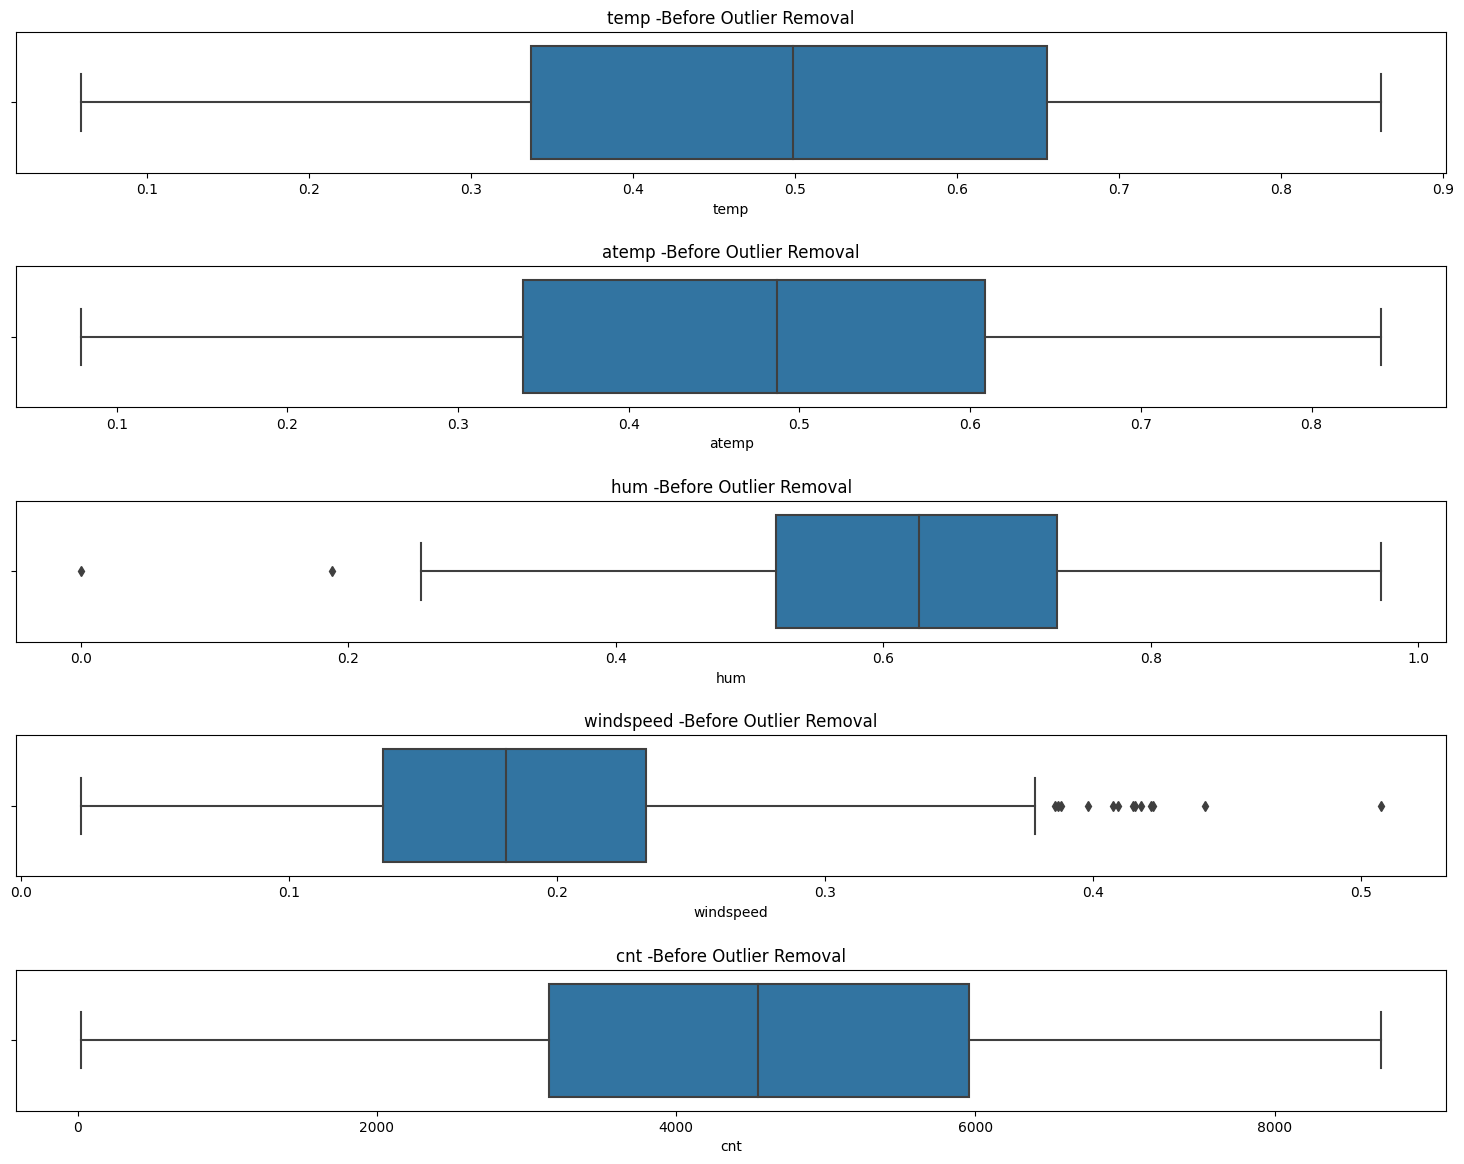

In [69]:

plt.figure(figsize=(15, 12))
cols= ["temp", "atemp", "hum", "windspeed", "cnt"]
for i, col in enumerate(cols):
    plt.subplot(len(cols), 1, i+1)
    sns.boxplot(x=data[col])
    plt.title(f"{col} -Before Outlier Removal")
    plt.tight_layout(pad=2)
data.shape

In [70]:
num_cols = ["temp", "atemp", "hum", "windspeed"]

for col in num_cols:
    Q1 = data[col].quantile(0.25)
    Q3 = data[col].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    data = data[(data[col] >= lower) & (data[col] <= upper)]

data.shape


(717, 11)

/tmp/ipykernel_47/3454021619.py:7: UserWarning: The figure layout has changed to tight
  plt.tight_layout(pad=2)
/tmp/ipykernel_47/3454021619.py:7: UserWarning: The figure layout has changed to tight
  plt.tight_layout(pad=2)
/tmp/ipykernel_47/3454021619.py:7: UserWarning: The figure layout has changed to tight
  plt.tight_layout(pad=2)
/tmp/ipykernel_47/3454021619.py:7: UserWarning: The figure layout has changed to tight
  plt.tight_layout(pad=2)


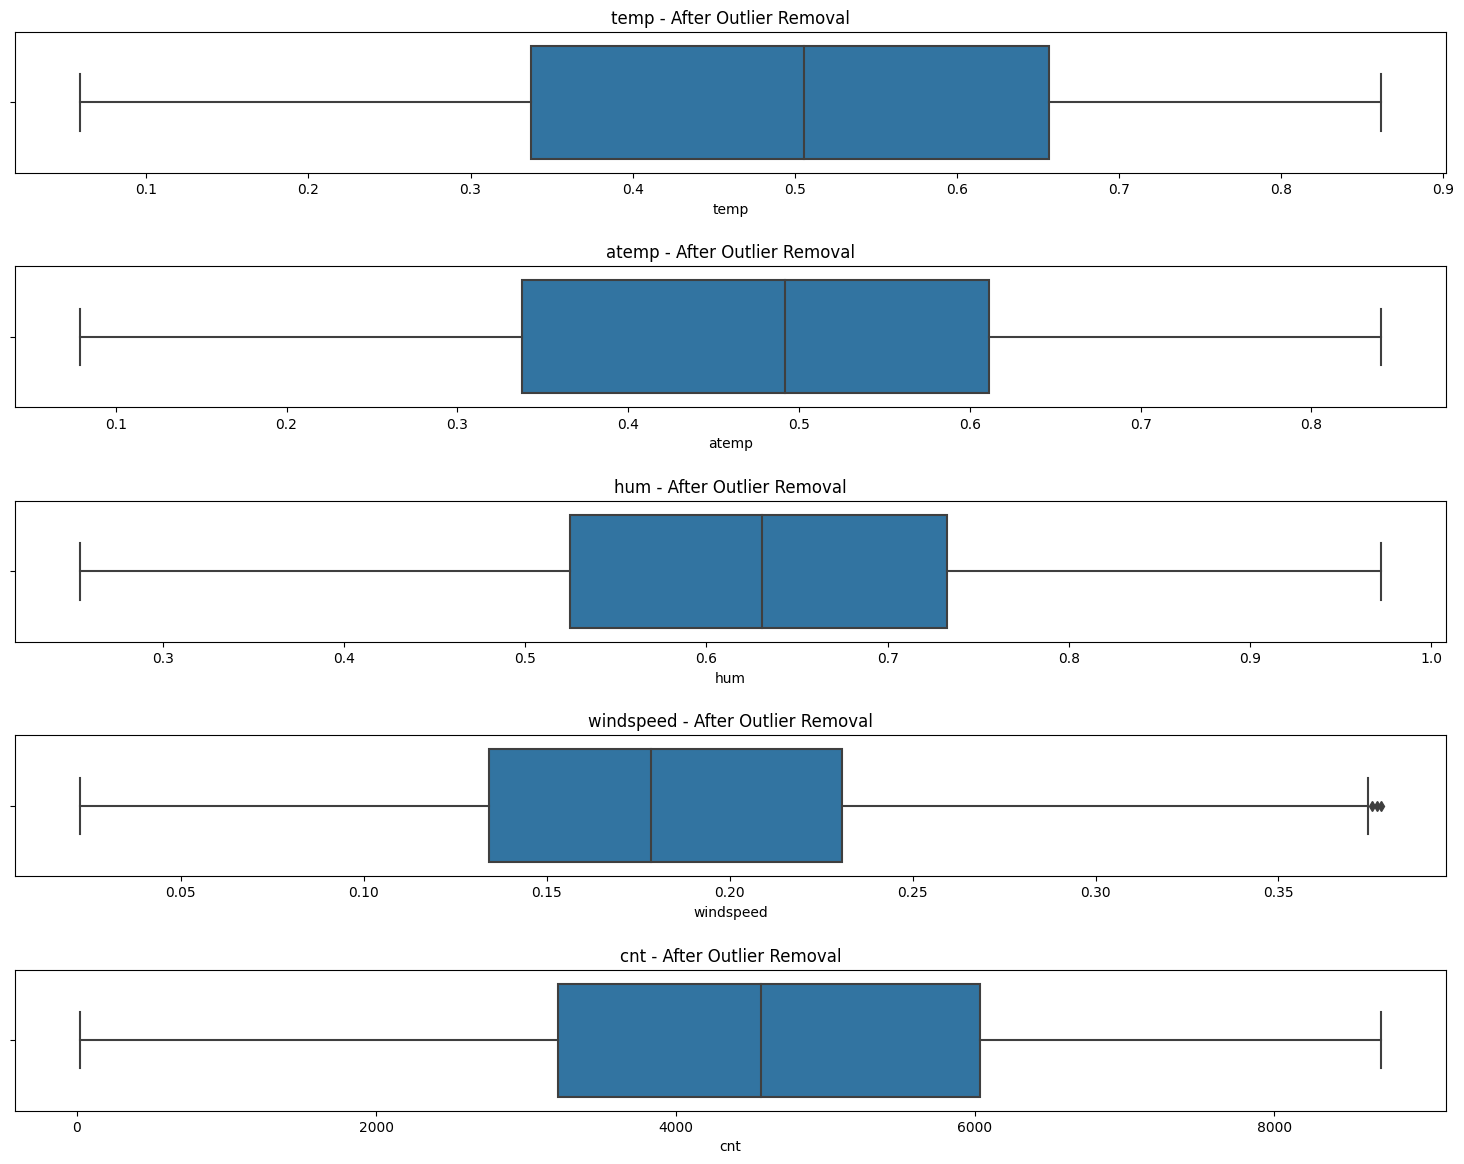

In [71]:

plt.figure(figsize=(15, 12))
cols= ["temp", "atemp", "hum", "windspeed", "cnt"]
for i, col in enumerate(cols):
    plt.subplot(len(cols), 1, i+1)
    sns.boxplot(x=data[col])
    plt.title(f"{col} - After Outlier Removal")
    plt.tight_layout(pad=2)


**removing outliers for hour.csv**

/tmp/ipykernel_47/564377328.py:7: UserWarning: The figure layout has changed to tight
  plt.tight_layout(pad=2)
/tmp/ipykernel_47/564377328.py:7: UserWarning: The figure layout has changed to tight
  plt.tight_layout(pad=2)
/tmp/ipykernel_47/564377328.py:7: UserWarning: The figure layout has changed to tight
  plt.tight_layout(pad=2)
/tmp/ipykernel_47/564377328.py:7: UserWarning: The figure layout has changed to tight
  plt.tight_layout(pad=2)


(17379, 12)

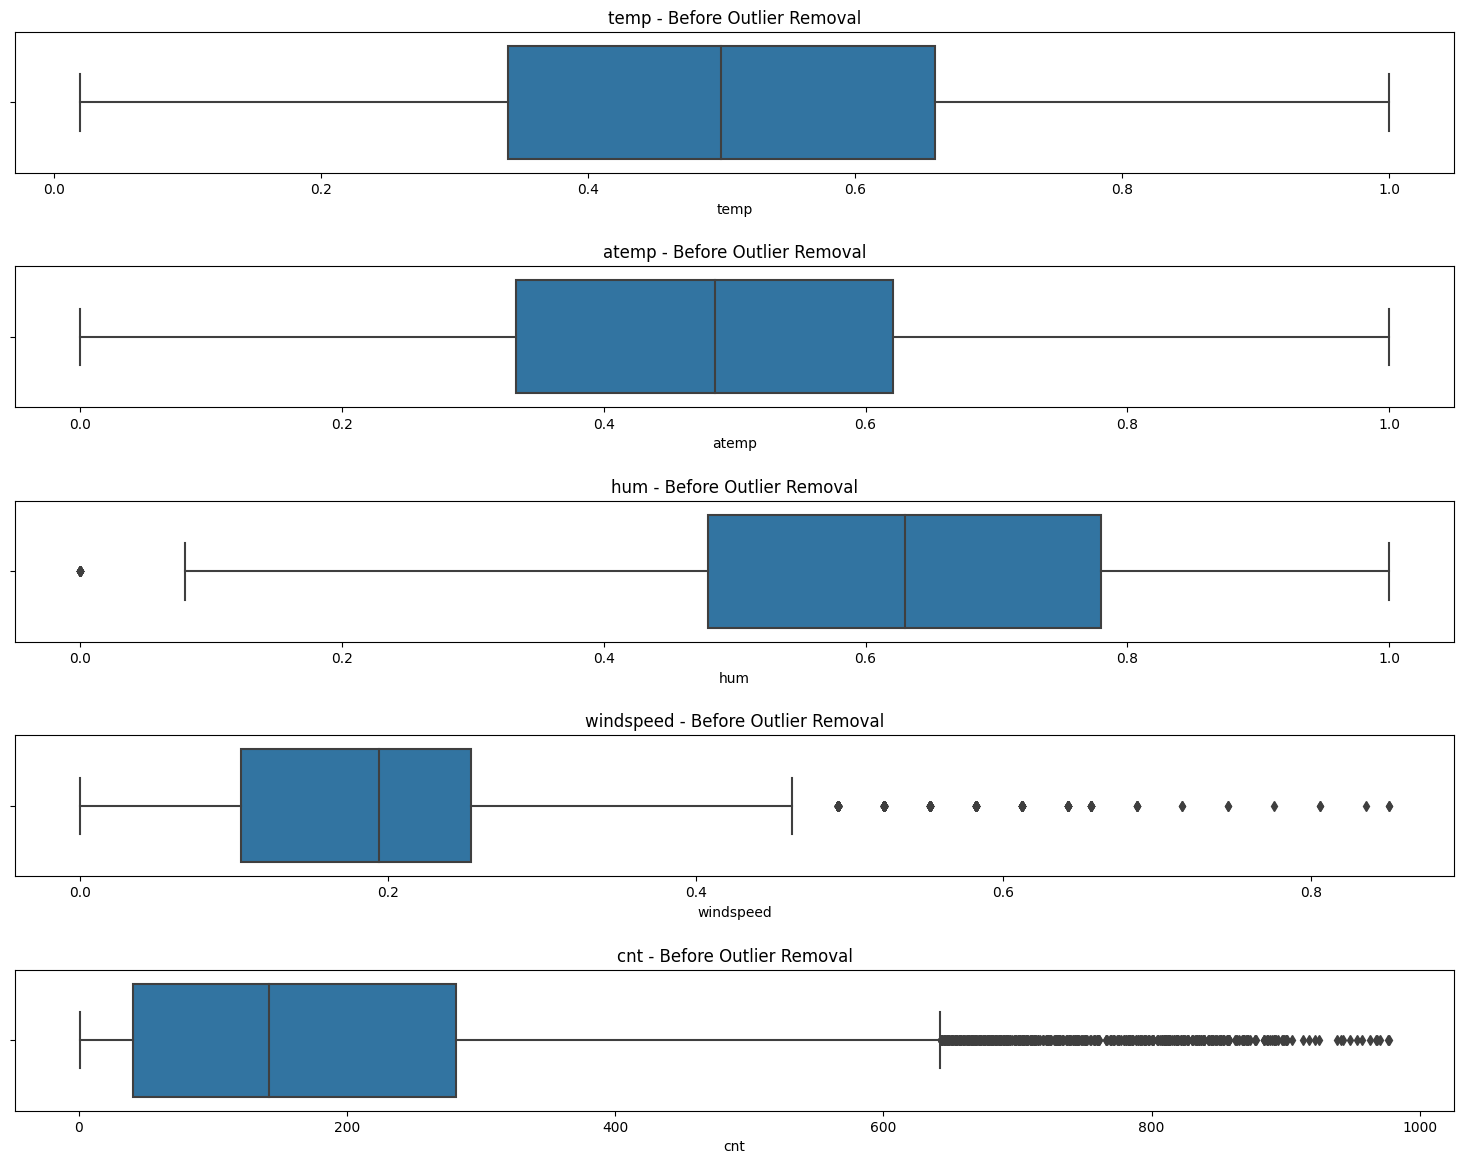

In [72]:

plt.figure(figsize=(15, 12))
cols= ["temp", "atemp", "hum", "windspeed", "cnt"]
for i, col in enumerate(cols):
    plt.subplot(len(cols), 1, i+1)
    sns.boxplot(x=data2[col])
    plt.title(f"{col} - Before Outlier Removal")
    plt.tight_layout(pad=2)
data2.shape

In [73]:
num_cols = data2.select_dtypes(include=['float64','int64']).columns

for col in num_cols:
    Q1 = data2[col].quantile(0.25)
    Q3 = data2[col].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    data2 = data2[(data2[col] >= lower) & (data2[col] <= upper)]

data2.shape


(16042, 12)

/tmp/ipykernel_47/806240041.py:7: UserWarning: The figure layout has changed to tight
  plt.tight_layout(pad=2)
/tmp/ipykernel_47/806240041.py:7: UserWarning: The figure layout has changed to tight
  plt.tight_layout(pad=2)
/tmp/ipykernel_47/806240041.py:7: UserWarning: The figure layout has changed to tight
  plt.tight_layout(pad=2)
/tmp/ipykernel_47/806240041.py:7: UserWarning: The figure layout has changed to tight
  plt.tight_layout(pad=2)


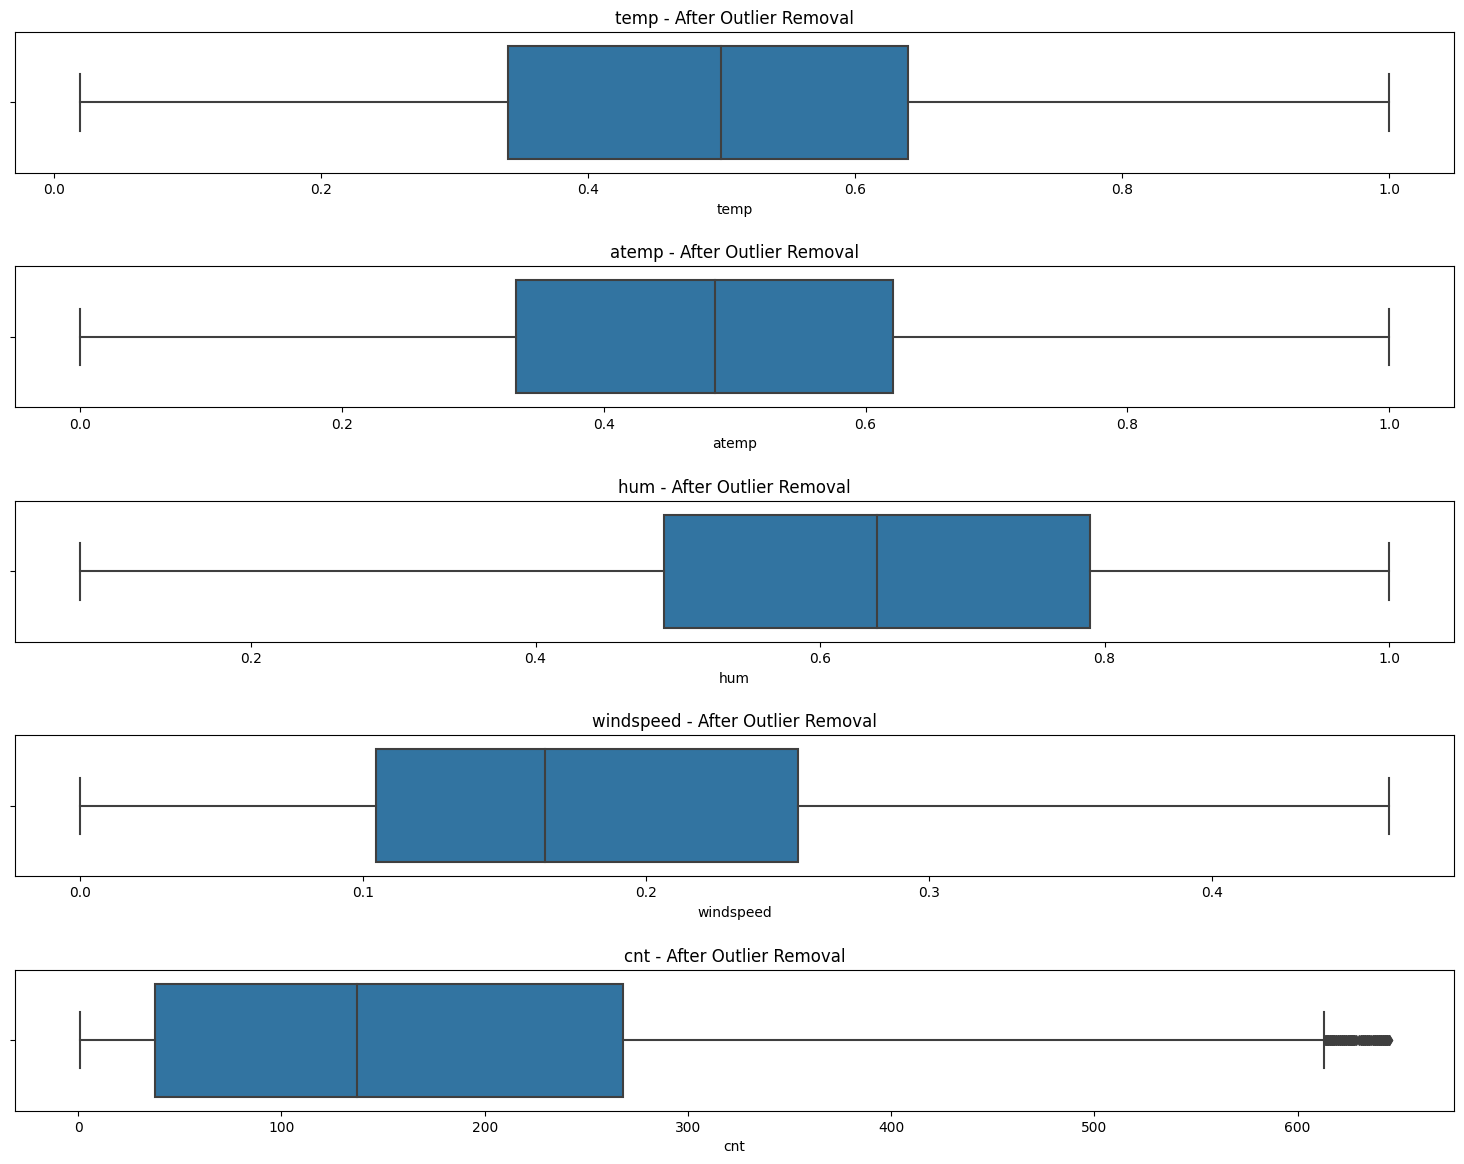

In [74]:

plt.figure(figsize=(15, 12))
cols= ["temp", "atemp", "hum", "windspeed", "cnt"]
for i, col in enumerate(cols):
    plt.subplot(len(cols), 1, i+1)
    sns.boxplot(x=data2[col])
    plt.title(f"{col} - After Outlier Removal")
    plt.tight_layout(pad=2)


In [75]:
X_day = data.drop("cnt", axis=1)
y_day = data["cnt"]

X_day_train, X_day_test, y_day_train, y_day_test = train_test_split(
    X_day, y_day, test_size=0.2, random_state=42
)

model_day = RandomForestRegressor()
model_day.fit(X_day_train, y_day_train)

pred_day = model_day.predict(X_day_test)

print("MODEL 1 (Day Data)")
print("MAE:", mean_absolute_error(y_day_test, pred_day))
print("R2:", r2_score(y_day_test, pred_day))

MODEL 1 (Day Data)
MAE: 969.2571527777776
R2: 0.643224764589535


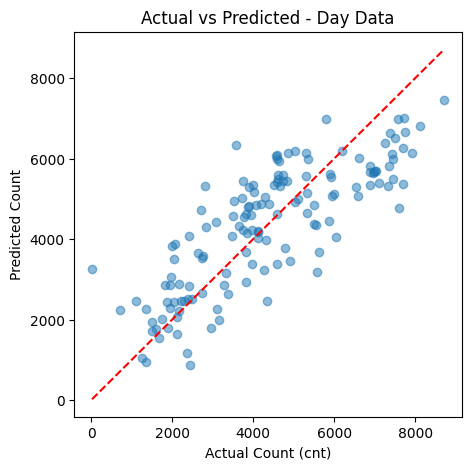

In [76]:
import matplotlib.pyplot as plt

plt.figure(figsize=(5,5))
plt.scatter(y_day_test, pred_day, alpha=0.5)
plt.xlabel("Actual Count (cnt)")
plt.ylabel("Predicted Count")
plt.title("Actual vs Predicted - Day Data")
plt.plot([y_day_test.min(), y_day_test.max()],
         [y_day_test.min(), y_day_test.max()],
         'r--')
plt.show()


In [77]:
X_hour = data2.drop("cnt", axis=1)
y_hour = data2["cnt"]

X_hour_train, X_hour_test, y_hour_train, y_hour_test = train_test_split(
    X_hour, y_hour, test_size=0.2, random_state=42
)

model_hour = RandomForestRegressor()
model_hour.fit(X_hour_train, y_hour_train)

pred_hour = model_hour.predict(X_hour_test)

print("MODEL 2 (Hour Data)")
print("MAE:", mean_absolute_error(y_hour_test, pred_hour))
print("R2:", r2_score(y_hour_test, pred_hour))

MODEL 2 (Hour Data)
MAE: 38.38228993975278
R2: 0.8635887105856083


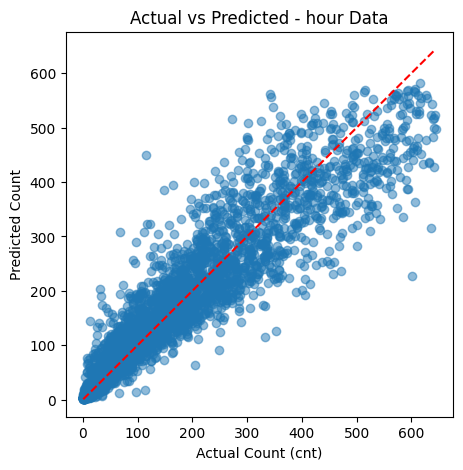

In [78]:
import matplotlib.pyplot as plt

plt.figure(figsize=(5,5))
plt.scatter(y_hour_test, pred_hour, alpha=0.5)
plt.xlabel("Actual Count (cnt)")
plt.ylabel("Predicted Count")
plt.title("Actual vs Predicted - hour Data")
plt.plot([y_hour_test.min(), y_hour_test.max()],
         [y_hour_test.min(), y_hour_test.max()],
         'r--')
plt.show()


HYPERPARAMETER TUNING

In [79]:

data_fe = data.copy()

data_fe['cnt_lag1'] = data_fe['cnt'].shift(1)
data_fe['cnt_lag2'] = data_fe['cnt'].shift(2)
data_fe['cnt_lag7'] = data_fe['cnt'].shift(7)

data_fe['cnt_roll3'] = data_fe['cnt'].shift(1).rolling(3).mean()
data_fe['cnt_roll7'] = data_fe['cnt'].shift(1).rolling(7).mean()

data_fe = data_fe.dropna()
data_fe['mnth_sin'] = np.sin(2 * np.pi * data_fe['mnth'] / 12)
data_fe['mnth_cos'] = np.cos(2 * np.pi * data_fe['mnth'] / 12)

data_fe['weekday_sin'] = np.sin(2 * np.pi * data_fe['weekday'] / 7)
data_fe['weekday_cos'] = np.cos(2 * np.pi * data_fe['weekday'] / 7)

X_day = data_fe.drop("cnt", axis=1)
y_day = data_fe["cnt"]

X_day_train, X_day_test, y_day_train, y_day_test = train_test_split(
    X_day, y_day, test_size=0.2, shuffle=False
)

xgb_day = XGBRegressor(
    n_estimators=100,
    max_depth=3,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    reg_alpha=0.5,
    reg_lambda=10,
    random_state=42
)

xgb_day.fit(X_day_train, y_day_train)

pred_train = xgb_day.predict(X_day_train)
pred_test = xgb_day.predict(X_day_test)
r2_train = r2_score(y_day_train, pred_train)
r2_test = r2_score(y_day_test, pred_test)
mae_train = mean_absolute_error(y_day_train, pred_train)
mae_test = mean_absolute_error(y_day_test, pred_test)

overfit_gap = abs(r2_train - r2_test)
final_score = r2_test - 0.5 * overfit_gap

print("DAY DATASET (XGBOOST)")
print("MAE Train :", mae_train)
print("MAE Test  :", mae_test)
print("R² Train  :", r2_train)
print("R² Test   :", r2_test)
print("Overfit Gap:", overfit_gap)
print("Final Score:", final_score)

DAY DATASET (XGBOOST)
MAE Train : 360.7634132277798
MAE Test  : 793.2954368054027
R² Train  : 0.9242595767672451
R² Test   : 0.7026993485086419
Overfit Gap: 0.22156022825860322
Final Score: 0.5919192343793402


In [80]:
param_grid_hour = {
    'n_estimators': [200, 300],
    'max_depth': [10, 15],
    'min_samples_split': [5, 10],
    'min_samples_leaf': [2, 4],
    'max_features': ['sqrt']
}

rf_hour = RandomForestRegressor(random_state=42)

grid_hour = GridSearchCV(
    estimator=rf_hour,
    param_grid=param_grid_hour,
    cv=3,
    scoring='r2',
    n_jobs=-1
)

grid_hour.fit(X_hour_train, y_hour_train)

best_hour_model = grid_hour.best_estimator_
pred_hour_tuned = best_hour_model.predict(X_hour_test)

print("\nHOUR DATASET (After Hyperparameter Tuning)")
print("MAE :", mean_absolute_error(y_hour_test, pred_hour_tuned))
print("R²  :", r2_score(y_hour_test, pred_hour_tuned))



HOUR DATASET (After Hyperparameter Tuning)
MAE : 45.74732137241302
R²  : 0.8178033838154269


In [81]:
r2_train_hour = best_hour_model.score(X_hour_train, y_hour_train)
r2_test_hour = r2_score(y_hour_test, pred_hour_tuned)
overfit_gap_hour = abs(r2_train_hour - r2_test_hour)
final_score_hour = r2_test_hour - 0.5 * overfit_gap_hour

print("\nHOUR DATASET")
print("R2 Train:", r2_train_hour)
print("R2 Test :", r2_test_hour)
print("Overfit Gap:", overfit_gap_hour)
print("Final Score:", final_score_hour)


HOUR DATASET
R2 Train: 0.9070852877477031
R2 Test : 0.8178033838154269
Overfit Gap: 0.0892819039322762
Final Score: 0.7731624318492889


In [82]:
import pandas as pd

hour_input = {
    'season': 2,
    'mnth': 6,
    'hr': 10,
    'holiday': 0,
    'weekday': 2,
    'workingday': 1,
    'weathersit': 1,
    'temp': 0.6,
    'atemp': 0.58,
    'hum': 0.4,
    'windspeed': 0.2
}

hour_preds = []
start_hour = hour_input['hr']

for i in range(7):
    temp_input = hour_input.copy()
    
    current_hour = (start_hour + i) % 24
    temp_input['hr'] = current_hour

    temp_input['temp'] = min(max(temp_input['temp'] + np.random.uniform(-0.02, 0.02), 0), 1)
    temp_input['hum'] = min(max(temp_input['hum'] + np.random.uniform(-0.05, 0.05), 0), 1)
    temp_input['windspeed'] = min(max(temp_input['windspeed'] + np.random.uniform(-0.02, 0.02), 0), 1)
    
    input_df = pd.DataFrame([temp_input])
    pred = best_hour_model.predict(input_df)[0]
    
    hour_label = f"{current_hour%12 if current_hour%12!=0 else 12} {'AM' if current_hour < 12 else 'PM'}"
    hour_preds.append([hour_label, round(pred, 2)])

hourly_output_df = pd.DataFrame(hour_preds, columns=["Hour", "Predicted cnt"])
hourly_output_df


,Hour,Predicted cnt
0,10 AM,247.29
1,11 AM,253.45
2,12 PM,259.85
3,1 PM,261.37
4,2 PM,256.40
5,3 PM,265.04
6,4 PM,380.62


In [83]:
import pandas as pd

last_day_row = X_day.iloc[-1].copy()

def daily_forecast_xgb(model, last_row, start_weekday, steps=7):
    day_map = ['Mon', 'Tue', 'Wed', 'Thu', 'Fri', 'Sat', 'Sun']
    results = []
    current_input = last_row.copy()
    current_day = start_weekday

    for _ in range(steps):
        current_input['weekday'] = current_day
        pred = model.predict(pd.DataFrame([current_input]))[0]
        results.append([day_map[current_day], round(pred, 2)])
        current_day = (current_day + 1) % 7

    return pd.DataFrame(results, columns=["Day", "Predicted cnt"])
daily_output_df = daily_forecast_xgb(
    xgb_day,          
    last_day_row,
    start_weekday=0,  
    steps=7
)

daily_output_df


,Day,Predicted cnt
0,Mon,1774.349976
1,Tue,1774.349976
2,Wed,1788.479980
3,Thu,1788.479980
4,Fri,1800.959961
5,Sat,1800.959961
6,Sun,1800.959961


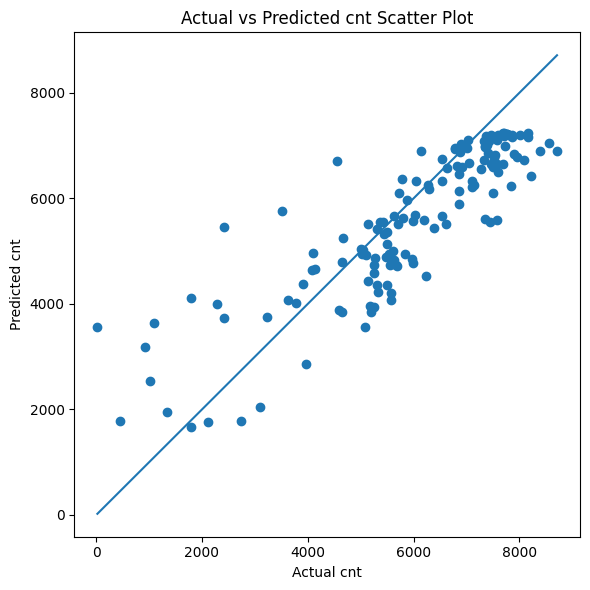

In [84]:
plt.figure(figsize=(6, 6))

plt.scatter(y_day_test, pred_test)
plt.plot([y_day_test.min(), y_day_test.max()],
         [y_day_test.min(), y_day_test.max()])

plt.xlabel("Actual cnt")
plt.ylabel("Predicted cnt")
plt.title("Actual vs Predicted cnt Scatter Plot")
plt.tight_layout()
plt.show()
